# Week 3: Feature review and further EDA


In [1]:
import zipfile
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


zip_path = "csv.zip"

with zipfile.ZipFile(zip_path) as z:
    files = {
        Path(name).name: name
        for name in z.namelist()
        if name.lower().endswith(".csv")
    }

drop_columns = [
    "employment_status_00", "high_bp_00", "high_cholesterol_00",
    "avg_drinks_p_day_00", "poor_health_days_00",
    "age_group_00", "education_level_00", "general_health_00", "last_checkup_00",
    "income_00", "income_01", "income_level_00", "income_level_01"
]

# Numeric features are summarized with statistics
numeric_features = [
    "bmi_00", "weight_00", "height_00",
    "mental_health_days_00", "physical_health_days_00"
]

# Categorical features are summarized by counts and percentages for each year.
categorical_features = [
    "age_00", "sex_00", "race_00", "marital_status_00", "education_00",
    "income", "gen_health_00", "exercise_00", "smoked_100_cigarettes_00",
    "drinks_alcohol_00", "had_stroke_00", "had_heart_attack_00",
    "had_coronary_heart_disease_00", "cost_barrier_00",
    "l_checkup_00", "has_personal_doctor_00"
]

candidate_features = numeric_features + categorical_features

expected_columns = sorted(candidate_features + ["diabetes", "year"])

# Proposed binary target for later modeling.
# The original diabetes labels are still kept in the summary tables.
target_map = {
    "Diabetic": 1,
    "Non-diabetic": 0,
    "Pre-diabetic": 0
}


## Read and summarize each year

Weight and height units still need to be confirmed from the processed-data documentation. The numeric checks below are for finding values that may need more review.


In [2]:
# Lists below collect one small summary at a time.
# They are combined into DataFrames after all 20 yearly files are processed.
overview_rows = []
numeric_rows = []
category_tables = []
missing_tables = []
association_tables = []

with zipfile.ZipFile(zip_path) as z:
    for year in range(2005, 2025):

        with z.open(files[f"DATASET_{year}.csv"]) as f:
            df = pd.read_csv(f, low_memory=False)

        weight_columns = df.columns.intersection(["_LLCPWT", "_FINALWT"]).tolist()

        if year <= 2020:
            income_source = "income_00"
            maximum_income_code = 8
        else:
            income_source = "income_01"
            maximum_income_code = 11

        income_raw = df[income_source]
        income = pd.to_numeric(income_raw, errors="coerce")

        # A conversion failure means the original value was present, but pandas could not convert it to a number.
        income_conversion_failures = int(
            (income_raw.notna() & income.isna()).sum()
        )

        # Keep only the expected code range for that year's income variable.
        valid_income = income.isin(range(1, maximum_income_code + 1))
        invalid_income = int((income.notna() & ~valid_income).sum())
        income = income.where(valid_income)

        income = income.replace({9: 8, 10: 8, 11: 8})

        clean = df.drop(
            columns=drop_columns + weight_columns,
            errors="ignore"
        ).copy()
        clean["income"] = income
        clean["year"] = year

        # Stop the notebook if a year does not have the expected prepared schema.
        if sorted(clean.columns) != expected_columns:
            raise ValueError(
                f"{year}: columns differ from the expected Week 2 set."
            )

        
        # --- NUMERIC FEATURE CHECKS ---
        for feature in numeric_features:
            raw = clean[feature]
            values = pd.to_numeric(raw, errors="coerce")

            conversion_failures = int(
                (raw.notna() & values.isna()).sum()
            )

            invalid = pd.Series(False, index=clean.index)

            if feature == "bmi_00":
                invalid = values.notna() & (values <= 0)

            if feature in [
                "mental_health_days_00",
                "physical_health_days_00"
            ]:
                invalid = values.notna() & ~values.between(0, 30)

            # Replace values that fail the basic rule with missing.
            clean[feature] = values.mask(invalid)
            values = clean[feature]

            # Store descriptive statistics for this feature and year.
            numeric_rows.append({
                "year": year,
                "feature": feature,
                "available_n": int(values.notna().sum()),
                "conversion_failures": conversion_failures,
                "values_changed_by_basic_check": int(invalid.sum()),
                "minimum": values.min(),
                "p01": values.quantile(0.01),
                "q25": values.quantile(0.25),
                "median": values.median(),
                "q75": values.quantile(0.75),
                "p99": values.quantile(0.99),
                "maximum": values.max()
            })

        
        # --- DIABETES TARGET CHECK ---
        # Make sure the target contains only the labels currently expected.
        unexpected_target = clean.loc[
            clean["diabetes"].notna()
            & ~clean["diabetes"].isin(target_map),
            "diabetes"
        ].unique()

        if len(unexpected_target):
            raise ValueError(
                f"{year}: unexpected target labels {unexpected_target}"
            )

        binary_target = clean["diabetes"].map(target_map)

        
        # --- YEAR OVERVIEW ---
        overview_rows.append({
            "year": year,
            "rows": len(clean),
            "columns": len(clean.columns),
            "period": "Training" if year <= 2020 else "Test",
            "income_conversion_failures": income_conversion_failures,
            "invalid_income_codes": invalid_income,
            "target_missing_n": int(binary_target.isna().sum()),
            "diabetic_n": int(binary_target.eq(1).sum()),
            "binary_target_available_n": int(binary_target.notna().sum()),
            "diabetic_pct_among_known_targets": binary_target.mean() * 100,
            "named_weight_columns": ", ".join(weight_columns) or "Not found"
        })

        
        # --- MISSING PERCENTAGE BY PREDICTOR ---
        missing_year = (
            clean[candidate_features]
            .isna()
            .mean()
            .mul(100)
            .rename_axis("feature")
            .reset_index(name="missing_pct")
        )
        missing_year["year"] = year
        missing_tables.append(missing_year)

        
        # --- CATEGORY COUNTS AND PERCANTAGES ---
        for feature in categorical_features + ["diabetes"]:
            # Convert labels to strings for the consistency
            labels = (
                clean[feature]
                .astype("string")
                .str.replace(r"\.0$", "", regex=True)
                .fillna("<missing>")
            )

            counts = (
                labels.value_counts()
                .rename_axis("category")
                .reset_index(name="count")
            )
            counts["year"] = year
            counts["feature"] = feature
            counts["percent_all_records"] = (
                counts["count"] / len(clean) * 100
            )
            category_tables.append(counts)

            
        # --- SIMPLE ASSOCIATION SUMMARIES ---
        # Only for the planned training years, just used to look at patterns before modeling
        if year <= 2020:
            for feature in ["age_00", "gen_health_00", "exercise_00"]:
                labels = (
                    clean[feature]
                    .astype("string")
                    .str.replace(r"\.0$", "", regex=True)
                    .fillna("<missing>")
                )

                pairs = pd.DataFrame({
                    "category": labels,
                    "target": binary_target
                })

                rates = (
                    pairs.groupby("category")["target"]
                    .agg(["count", "sum", "mean"])
                    .reset_index()
                    .rename(columns={
                        "count": "known_target_n",
                        "sum": "diabetic_n",
                        "mean": "diabetic_fraction"
                    })
                )

                rates["diabetic_pct"] = (
                    rates["diabetic_fraction"] * 100
                )
                rates = rates.drop(columns="diabetic_fraction")
                rates["year"] = year
                rates["feature"] = feature
                association_tables.append(rates)

        print(f"Finished {year}")

        del df, clean

Finished 2005
Finished 2006
Finished 2007
Finished 2008
Finished 2009
Finished 2010
Finished 2011
Finished 2012
Finished 2013
Finished 2014
Finished 2015
Finished 2016
Finished 2017
Finished 2018
Finished 2019
Finished 2020
Finished 2021
Finished 2022
Finished 2023
Finished 2024


## Create and check the summary tables

In [3]:
# Combine the lists created in the yearly loop.
overview = pd.DataFrame(overview_rows)
numeric_summary = pd.DataFrame(numeric_rows)
categories = pd.concat(category_tables, ignore_index=True)
missing = pd.concat(missing_tables, ignore_index=True)
associations = pd.concat(association_tables, ignore_index=True)

# Basic checks that should be true if the preparation ran as expected.
assert len(overview) == 20
assert overview["columns"].eq(23).all()

# For each year and categorical feature, the category counts should add up
# to the total number of processed records for that year.
category_totals = categories.groupby(
    ["year", "feature"]
)["count"].sum()

expected_totals = category_totals.index.get_level_values("year").map(
    overview.set_index("year")["rows"]
)

assert (
    category_totals.to_numpy()
    == expected_totals.to_numpy()
).all()

print("Run summary:")
display(overview.round(2))

print("Numeric checks: sums across all years:")
display(
    numeric_summary.groupby("feature")[[
        "conversion_failures",
        "values_changed_by_basic_check"
    ]].sum()
)

print("Numeric statistics for selected years:")
display(
    numeric_summary[
        numeric_summary["year"].isin(
            [2005, 2010, 2011, 2020, 2021, 2022, 2024]
        )
    ].round(2)
)

Run summary:


,year,rows,columns,period,income_conversion_failures,invalid_income_codes,target_missing_n,diabetic_n,binary_target_available_n,diabetic_pct_among_known_targets,named_weight_columns
0,2005,355446,23,Training,0,0,0,33317,355446,9.37,Not found
1,2006,354497,23,Training,0,0,0,36080,354497,10.18,Not found
2,2007,429942,23,Training,0,0,0,48068,429942,11.18,Not found
3,2008,412898,23,Training,0,0,0,47391,412898,11.48,Not found
4,2009,431636,23,Training,0,0,0,52381,431636,12.14,Not found
5,2010,449156,23,Training,0,0,0,57464,449156,12.79,Not found
6,2011,503846,23,Training,0,0,0,62456,503846,12.40,Not found
7,2012,473243,23,Training,0,0,0,59749,473243,12.63,Not found
8,2013,490368,23,Training,0,0,0,62341,490368,12.71,Not found
9,2014,461879,23,Training,0,0,0,61099,461879,13.23,Not found


Numeric checks: sums across all years:


,conversion_failures,values_changed_by_basic_check
feature,,
bmi_00,0,0
height_00,0,0
mental_health_days_00,0,0
physical_health_days_00,0,0
weight_00,0,0


Numeric statistics for selected years:


,year,feature,available_n,conversion_failures,values_changed_by_basic_check,minimum,p01,q25,median,q75,p99,maximum
0,2005,bmi_00,339086,0,0,2.06,17.75,23.29,26.36,29.98,46.05,143.69
1,2005,weight_00,341629,0,0,50.00,100.00,140.00,168.00,196.00,300.00,661.39
2,2005,height_00,351074,0,0,27.00,59.00,64.00,66.00,70.00,76.00,237.40
3,2005,mental_health_days_00,349156,0,0,0.00,0.00,0.00,0.00,2.00,30.00,30.00
4,2005,physical_health_days_00,347928,0,0,0.00,0.00,0.00,0.00,3.00,30.00,30.00
25,2010,bmi_00,427933,0,0,6.60,17.81,23.63,26.62,30.54,46.98,152.56
26,2010,weight_00,430634,0,0,50.00,100.00,144.00,170.00,200.00,300.00,724.00
27,2010,height_00,443233,0,0,29.00,59.00,63.00,66.00,69.00,76.00,95.00
28,2010,mental_health_days_00,440480,0,0,0.00,0.00,0.00,0.00,2.00,30.00,30.00
29,2010,physical_health_days_00,438158,0,0,0.00,0.00,0.00,0.00,3.00,30.00,30.00


- All 20 yearly files were processed with the same 23 prepared columns: 21 candidate predictors, the diabetes target, and year.
- Did not find income conversion failures or income codes outside the expected ranges.
- The processed diabetes target does not have missing values in these files.
- `_LLCPWT` and `_FINALWT` were not found in the processed CSV files.

The basic range checks did not flag any BMI values at or below zero. However, the wider numeric summary showed some very small and very large positive BMI and height values. For example:

| Year | Minimum BMI | Maximum BMI | Maximum processed height |
|---|---:|---:|---:|
| 2005 | 2.06 | 143.69 | 237.40 |
| 2011 | 6.42 | 265.46 | 124.80 |
| 2020 | 7.19 | 256.20 | 95.00 |
| 2022 | 0.96 | 233.25 | 296.06 |
| 2024 | 0.62 | 249.52 | 320.87 |

Need to understand how BMI, weight, and height were created in the processed dataset before deciding what to do with the extreme values.


In [4]:
bmi_check_rows = []
extreme_tables = []

review_years = [2005, 2011, 2020, 2022, 2024]

with zipfile.ZipFile(zip_path) as z:
    for year in range(2005, 2025):

        with z.open(files[f"DATASET_{year}.csv"]) as f:
            measurements = pd.read_csv(
                f,
                usecols=["bmi_00", "weight_00", "height_00"],
                low_memory=False
            )

        for feature in ["bmi_00", "weight_00", "height_00"]:
            measurements[feature] = pd.to_numeric(
                measurements[feature],
                errors="coerce"
            )

        bmi = measurements["bmi_00"]
        weight = measurements["weight_00"]
        height = measurements["height_00"]

        # A record can be used in this comparison only when BMI is available
        # and both weight and height are positive.
        paired = bmi.notna() & weight.gt(0) & height.gt(0)

        # Candidate formula:
        # BMI = weight_kg / height_m^2
        # Here I temporarily assume weight is in pounds and height is in inches.
        # This is a diagnostic assumption, not a final confirmation of the units.
        positive_height = height.where(height.gt(0))
        candidate_bmi = (
            weight * 0.45359237
            / (positive_height * 0.0254).pow(2)
        )
        candidate_bmi = candidate_bmi.where(paired)

        # Compare the calculated value with the BMI saved in the processed file.
        difference = (bmi - candidate_bmi).abs()
        paired_n = int(paired.sum())
        close_n = int(
            (paired & difference.le(0.10)).sum()
        )

        # Use broad review thresholds only to count unusual values.
        # These thresholds are not being used as automatic exclusion rules.
        bmi_check_rows.append({
            "year": year,
            "bmi_available_n": int(bmi.notna().sum()),
            "bmi_below_10_review_n": int(bmi.lt(10).sum()),
            "bmi_above_100_review_n": int(bmi.gt(100).sum()),
            "weight_equals_999_review_n": int(weight.eq(999).sum()),
            "paired_n": paired_n,
            "formula_close_pct": (
                close_n / paired_n * 100
                if paired_n else float("nan")
            ),
            "median_absolute_formula_difference": difference.median(),
            "p99_absolute_formula_difference": difference.quantile(0.99)
        })

        # Save a few low/high BMI examples for selected years so I can inspect
        # the related weight and height values rather than only seeing counts.
        if year in review_years:
            measurements["candidate_bmi_if_lb_in"] = candidate_bmi
            measurements["absolute_formula_difference"] = difference

            low = measurements.nsmallest(5, "bmi_00").copy()
            high = measurements.nlargest(5, "bmi_00").copy()

            low["review_group"] = "5 lowest BMI"
            high["review_group"] = "5 highest BMI"

            examples = pd.concat([low, high]).drop_duplicates()
            examples["year"] = year
            extreme_tables.append(examples)

        del measurements

bmi_diagnostic = pd.DataFrame(bmi_check_rows)

print("BMI/weight/height diagnostic:")
display(bmi_diagnostic.round(4))

print("Extreme examples with corresponding weight and height:")
display(
    pd.concat(extreme_tables, ignore_index=True).round(4)
)

BMI/weight/height diagnostic:


,year,bmi_available_n,bmi_below_10_review_n,bmi_above_100_review_n,weight_equals_999_review_n,paired_n,formula_close_pct,median_absolute_formula_difference,p99_absolute_formula_difference
0,2005,339086,14,6,0,339086,100.0000,0.0026,0.0080
1,2006,337134,17,17,0,337134,100.0000,0.0026,0.0080
2,2007,410151,10,13,0,410151,100.0000,0.0026,0.0081
3,2008,394341,37,9,0,394341,100.0000,0.0026,0.0081
4,2009,411912,20,7,0,411912,100.0000,0.0026,0.0081
5,2010,427933,32,8,0,427933,100.0000,0.0026,0.0081
6,2011,479463,27,21,0,479463,100.0000,0.0026,0.0081
7,2012,450764,38,8,0,450764,100.0000,0.0027,0.0081
8,2013,466831,34,20,0,466831,99.9998,0.0027,0.0082
9,2014,434161,19,19,0,434161,99.9998,0.0026,0.0082


Extreme examples with corresponding weight and height:


,weight_00,height_00,bmi_00,candidate_bmi_if_lb_in,absolute_formula_difference,review_group,year
0,158.00,232.28,2.06,2.0589,0.0011,5 lowest BMI,2005
1,165.00,236.22,2.08,2.0790,0.0010,5 lowest BMI,2005
2,220.00,237.40,2.74,2.7445,0.0045,5 lowest BMI,2005
3,220.00,237.01,2.75,2.7535,0.0035,5 lowest BMI,2005
4,270.00,237.01,3.38,3.3793,0.0007,5 lowest BMI,2005
5,149.00,27.00,143.69,143.7001,0.0101,5 highest BMI,2005
6,136.69,27.56,126.51,126.5251,0.0151,5 highest BMI,2005
7,606.00,60.00,118.34,118.3500,0.0100,5 highest BMI,2005
8,661.39,63.00,117.15,117.1588,0.0088,5 highest BMI,2005
9,602.00,64.00,103.32,103.3320,0.0120,5 highest BMI,2005


- The saved BMI values ~ the BMI calculated from the processed weight (lbs) and height (inches) columns.
- The comparison is close for almost all paired records, so the three processed columns appear to be related in a consistent way.
- 612 BMI values below 10 and 464 above 100 across all years.
- 25 records where processed weight equals 999.

For now, I am keeping these values and documenting the issue. I will check the preprocessing information before deciding whether any numeric limits or exclusions are needed.


## Working data dictionary

In [5]:
# "Predictor candidate" means the feature is still being considered

dictionary_rows = [('age_00',
  'Ordered age group',
  'Predictor candidate',
  'Age group code; not exact age. _AGEG5YR source in prior review.'),
 ('sex_00',
  'Category',
  'Predictor candidate',
  'Respondent sex; source construction changes over time.'),
 ('race_00',
  'Category',
  'Predictor candidate',
  'Race/ethnicity label; flag the 2022 category difference.'),
 ('marital_status_00', 'Category', 'Predictor candidate', 'Marital status.'),
 ('education_00',
  'Ordered category',
  'Predictor candidate',
  'Education level code; confirm code-to-label mapping.'),
 ('income',
  'Ordered category',
  'Predictor candidate',
  '1–8 annual household income groups; newer top groups combined.'),
 ('gen_health_00',
  'Ordered category',
  'Predictor candidate',
  'General health code; confirm code-to-label mapping.'),
 ('exercise_00',
  'Category',
  'Predictor candidate',
  'Reported exercise/physical activity in the past 30 days.'),
 ('smoked_100_cigarettes_00',
  'Category',
  'Predictor candidate',
  'History of smoking at least 100 cigarettes; not current smoking status.'),
 ('drinks_alcohol_00', 'Category', 'Predictor candidate', 'Any alcohol use in the past 30 days.'),
 ('had_stroke_00', 'Category', 'Predictor candidate', 'Self-reported history of stroke.'),
 ('had_heart_attack_00',
  'Category',
  'Predictor candidate',
  'Self-reported history of heart attack.'),
 ('had_coronary_heart_disease_00',
  'Category',
  'Predictor candidate',
  'Self-reported coronary heart disease/angina history.'),
 ('cost_barrier_00',
  'Category',
  'Predictor candidate',
  'Needed care but could not see a doctor because of cost in the past year.'),
 ('l_checkup_00',
  'Ordered category',
  'Predictor candidate',
  'Time since routine checkup; confirm processed code-to-label mapping.'),
 ('has_personal_doctor_00',
  'Category',
  'Predictor candidate',
  'Personal provider responses; wording broadens in 2021.'),
 ('bmi_00',
  'Numeric',
  'Predictor candidate',
  'Processed BMI (kg/m²); full calculation rules still need verification.'),
 ('weight_00',
  'Numeric',
  'Predictor candidate',
  'Processed body weight; unit must be verified before using it.'),
 ('height_00',
  'Numeric',
  'Predictor candidate',
  'Processed height; unit must be verified before using it.'),
 ('mental_health_days_00',
  'Numeric count',
  'Predictor candidate',
  'Days of poor mental health during the past 30 days; 0–30.'),
 ('physical_health_days_00',
  'Numeric count',
  'Predictor candidate',
  'Days of poor physical health during the past 30 days; 0–30.'),
 ('diabetes',
  'Category',
  'Original target',
  'Diabetic, Non-diabetic, Pre-diabetic; keep original classes for audit.'),
 ('year',
  'Integer',
  'Split metadata',
  'Survey year. Do not include it as a predictor in the planned fixed temporal model.')]
data_dictionary = pd.DataFrame(dictionary_rows, columns=[
    "column", "type", "role", "definition_and_note"
])

observed_2020 = categories[categories["year"].eq(2020)]
observed_labels = observed_2020.groupby("feature")["category"].agg(
    lambda labels: "; ".join(sorted(labels))
)
data_dictionary["observed_categories_2020"] = data_dictionary["column"].map(observed_labels)
data_dictionary["observed_categories_2020"] = (
    data_dictionary["observed_categories_2020"].fillna("See numeric summary / survey year")
)

pd.set_option("display.max_colwidth", 110)
display(data_dictionary)

,column,type,role,definition_and_note,observed_categories_2020
0,age_00,Ordered age group,Predictor candidate,Age group code; not exact age. _AGEG5YR source in prior review.,1; 10; 11; 12; 13; 2; 3; 4; 5; 6; 7; 8; 9; <missing>
1,sex_00,Category,Predictor candidate,Respondent sex; source construction changes over time.,Female; Male
2,race_00,Category,Predictor candidate,Race/ethnicity label; flag the 2022 category difference.,<missing>; American Indian or Alaskan Native; Asian; Black; Hispanic; Multiracial; Native Hawaiian or othe...
3,marital_status_00,Category,Predictor candidate,Marital status.,<missing>; A member of an unmarried couple; Divorced; Married; Never married; Separated; Widowed
4,education_00,Ordered category,Predictor candidate,Education level code; confirm code-to-label mapping.,1; 2; 3; 4; 5; 6; <missing>
5,income,Ordered category,Predictor candidate,1–8 annual household income groups; newer top groups combined.,1; 2; 3; 4; 5; 6; 7; 8; <missing>
6,gen_health_00,Ordered category,Predictor candidate,General health code; confirm code-to-label mapping.,1; 2; 3; 4; 5; <missing>
7,exercise_00,Category,Predictor candidate,Reported exercise/physical activity in the past 30 days.,<missing>; False; True
8,smoked_100_cigarettes_00,Category,Predictor candidate,History of smoking at least 100 cigarettes; not current smoking status.,<missing>; False; True
9,drinks_alcohol_00,Category,Predictor candidate,Any alcohol use in the past 30 days.,<missing>; False; True


## Year-to-year items that still need attention

I am keeping these notes so I do not forget them when I finalize the features.

| Item | What I found so far | Current plan |
|---|---|---|
| 2011 survey methods | BRFSS changed sampling/weighting methods around 2011 | Mark 2011 on some plots and be careful when reading changes across that point |
| Income, 2021 | The newer income variable has more upper-income codes | Combine the newer top codes into the older group 8 |
| Personal provider, 2021 | The source wording changed and the processed responses also shift | Keep the flag and review before final encoding |
| Race, 2022 | The processed 2022 file does not show an “Other” category | Keep the category as observed; do not create replacement records |
| BMI | The processed BMI is not simply the raw CDC `_BMI5` field | Continue checking formula, units, and unusual values |
| Other source changes | Earlier review noted changes for sex, alcohol, and cardiovascular-history fields | Keep notes and check if any category patterns look unusual |
| Survey weights | `_LLCPWT` and `_FINALWT` are not in these processed files | Treat current EDA as unweighted and document this limitation |

Employment remains out of the main all-year set because the processed 2024 column was missing. High blood pressure and high cholesterol also stay outside the main 2005–2024 analysis because they are not available in every year. I plan to look at those separately later if time allows.


## 5. Feature distributions during the training period

The next plots use only 2005–2020, which is the planned training period. I am using them to see whether some category shares look fairly stable or change over time.

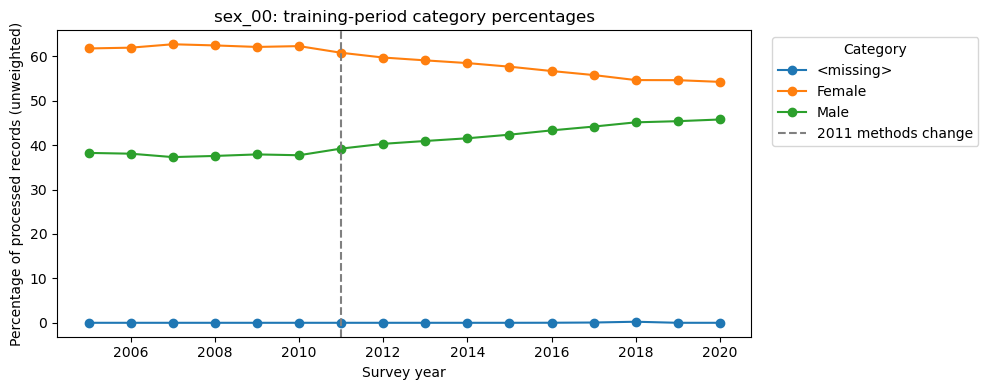

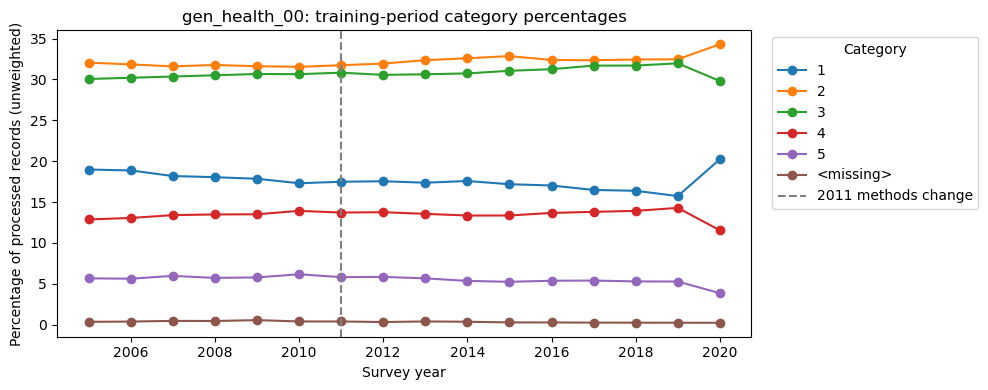

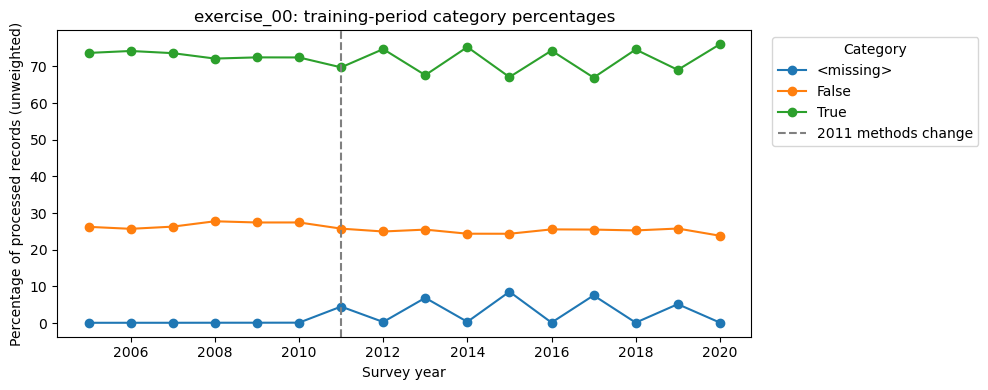

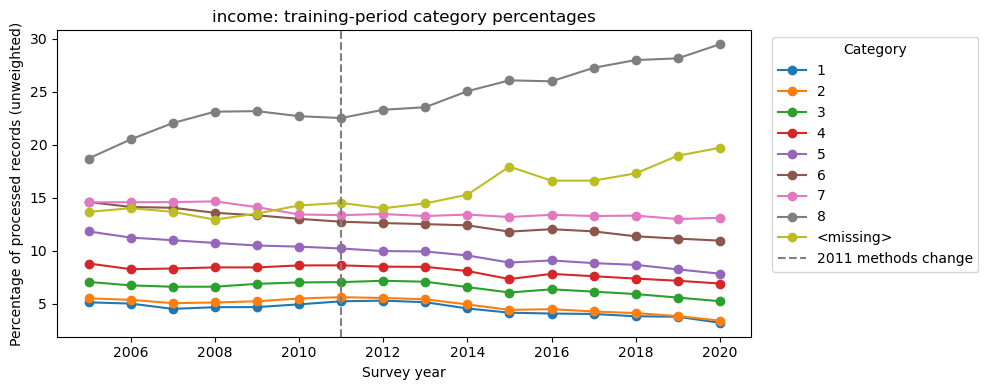

In [6]:
training_categories = categories[categories["year"].le(2020)]

# Plot a small set of features that are useful examples of different patterns.
# Each line is the percentage of all processed records in one category.
for feature in ["sex_00", "gen_health_00", "exercise_00", "income"]:
    focus = training_categories[
        training_categories["feature"].eq(feature)
    ]

    trend = focus.pivot(
        index="year",
        columns="category",
        values="percent_all_records"
    ).fillna(0)

    trend.plot(marker="o", figsize=(10, 4))

    # Mark 2011 because the BRFSS survey methods changed around this time.
    plt.axvline(
        2011,
        color="gray",
        linestyle="--",
        label="2011 methods change"
    )

    plt.title(f"{feature}: training-period category percentages")
    plt.xlabel("Survey year")
    plt.ylabel("Percentage of processed records (unweighted)")
    plt.legend(
        title="Category",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )
    plt.tight_layout()
    plt.show()

Largest category range for each feature, 2005–2020:


,range_percentage_points
feature,
had_stroke_00,1.1
had_heart_attack_00,1.25
had_coronary_heart_disease_00,1.25
cost_barrier_00,4.03
age_00,4.3
gen_health_00,4.5
race_00,5.04
has_personal_doctor_00,5.15
education_00,6.52


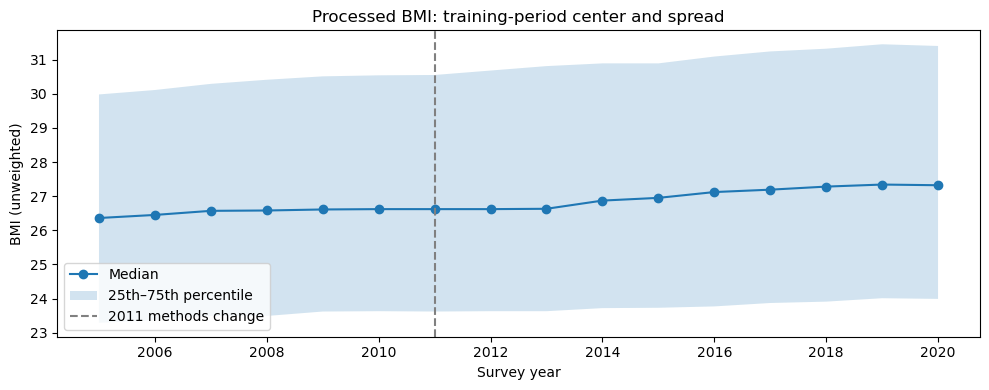

In [7]:
# For each category, calculate how much its percentage changes
# between its highest and lowest training-year values.
# Then keep the largest category range for each feature.

category_trends = training_categories.pivot_table(
    index=["feature", "category"],
    columns="year",
    values="percent_all_records"
).fillna(0)

category_ranges = (
    category_trends.max(axis=1)
    - category_trends.min(axis=1)
).rename("range_percentage_points").reset_index()

category_ranges = category_ranges[
    category_ranges["feature"].ne("diabetes")
]

feature_ranges = (
    category_ranges.groupby("feature")[
        "range_percentage_points"
    ].max()
)

print("Largest category range for each feature, 2005–2020:")
display(
    feature_ranges.sort_values().round(2).to_frame()
)

# Show the yearly BMI median and the middle 50% (Q1 to Q3).
training_numeric = numeric_summary[
    numeric_summary["year"].le(2020)
]

bmi_trend = training_numeric[
    training_numeric["feature"].eq("bmi_00")
]

plt.figure(figsize=(10, 4))
plt.plot(
    bmi_trend["year"],
    bmi_trend["median"],
    marker="o",
    label="Median"
)

plt.fill_between(
    bmi_trend["year"],
    bmi_trend["q25"],
    bmi_trend["q75"],
    alpha=0.2,
    label="25th–75th percentile"
)

plt.axvline(
    2011,
    color="gray",
    linestyle="--",
    label="2011 methods change"
)

plt.title("Processed BMI: training-period center and spread")
plt.xlabel("Survey year")
plt.ylabel("BMI (unweighted)")
plt.legend()
plt.tight_layout()
plt.show()

### Notes from the training-period distributions

- The cardiovascular-history features have relatively small category-percentage changes.
- Income changes more than most of the other displayed features. The highest income group becomes more common over time, and the missing share also changes.
- General health is more stable than income.
- Exercise has noticeable changes in missing responses in some years.
- The BMI median rises from 26.36 in 2005 to 27.32 in 2020, and the middle 50% also shifts somewhat.

## Initial diabetes rates by selected features

The tables will show the diabetic percentage within selected feature categories for the training years.

age_00 — diabetic percentage among known targets:


year,2005,2010,2011,2015,2020
category,,,,,
1,0.91,1.09,1.07,0.94,1.15
10,17.82,19.71,19.89,20.36,19.80
11,18.47,21.34,21.48,21.93,22.19
12,17.53,20.64,21.36,21.73,22.97
13,14.19,16.71,17.03,18.05,18.92
2,1.52,2.03,1.64,1.43,1.51
3,2.25,2.63,2.37,2.27,2.60
4,3.30,3.82,3.90,4.01,4.12
5,4.49,5.22,5.51,6.13,6.35


Corresponding denominators:


year,2005,2010,2011,2015,2020
category,,,,,
1,18275,12613,22833,24139,25561
10,25494,45448,47651,49110,41270
11,21977,37121,39003,38245,37684
12,18772,29707,31490,28164,26483
13,20971,39322,41953,36645,31304
2,20580,13621,21749,19699,20860
3,25961,21221,27358,22867,23309
4,29787,26904,29678,24462,25365
5,33509,31480,34839,25830,25546


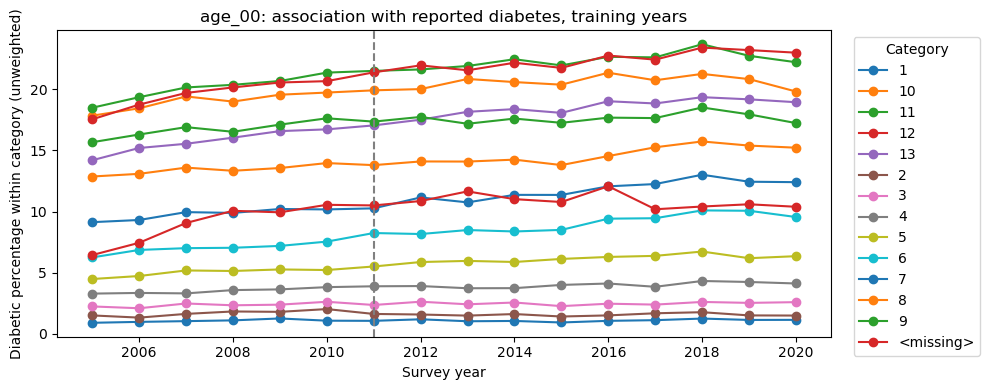

gen_health_00 — diabetic percentage among known targets:


year,2005,2010,2011,2015,2020
category,,,,,
1,1.52,2.23,2.07,2.43,2.95
2,3.95,5.96,5.75,6.53,7.47
3,10.40,14.68,14.31,15.47,16.76
4,21.92,27.08,26.95,27.84,29.62
5,31.99,35.40,34.91,35.59,36.96
<missing>,15.98,17.74,16.94,20.59,18.49


Corresponding denominators:


year,2005,2010,2011,2015,2020
category,,,,,
1,67477,77736,88101,75598,80754
2,113959,141698,159963,144557,136917
3,106848,137682,155351,136643,118969
4,45767,62550,69130,58769,46094
5,20150,27709,29312,23085,15391
<missing>,1245,1781,1989,1229,925


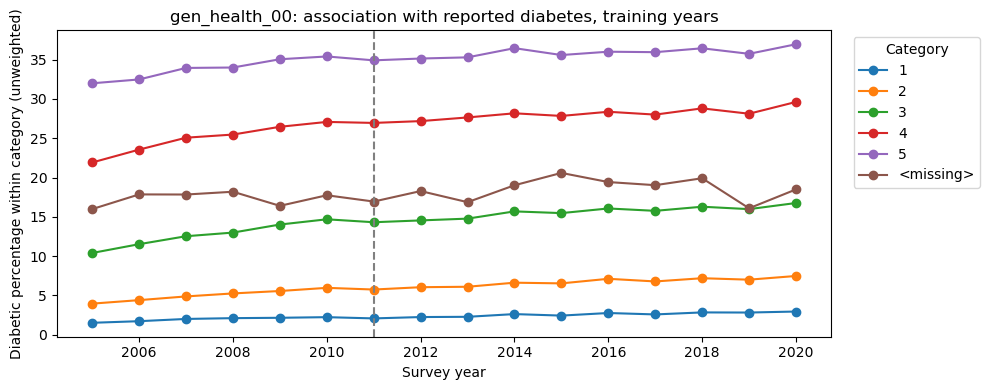

exercise_00 — diabetic percentage among known targets:


year,2005,2010,2011,2015,2020
category,,,,,
<missing>,14.63,15.78,12.70,12.12,18.84
False,14.69,18.96,17.93,19.26,21.40
True,7.47,10.45,10.33,10.86,10.42


Corresponding denominators:


year,2005,2010,2011,2015,2020
category,,,,,
<missing>,369,621,22779,37707,637
False,93305,123284,129816,107192,95106
True,261772,325251,351251,294982,303307


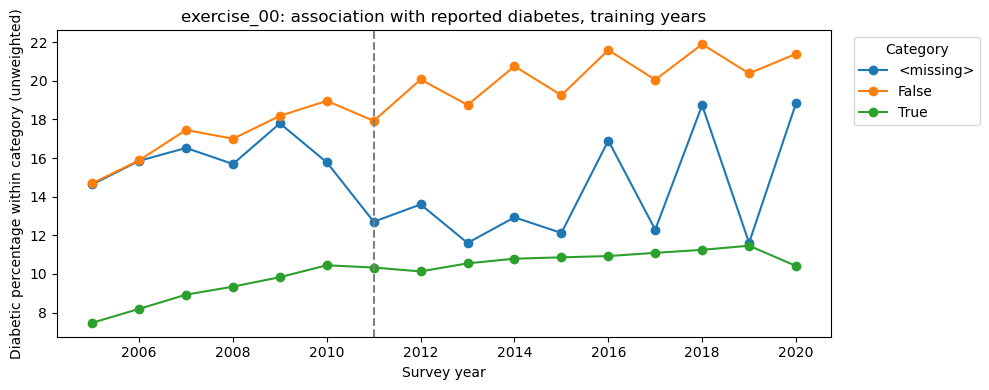

In [8]:
# Look at diabetes rates for a few selected features in the training years.
# The same selected years are displayed in tables so the notebook is easier to read.

display_years = [2005, 2010, 2011, 2015, 2020]

for feature in ["age_00", "gen_health_00", "exercise_00"]:
    focus = associations[
        associations["feature"].eq(feature)
    ]

    # Percentage of known binary targets that are diabetic.
    rate_table = focus.pivot(
        index="category",
        columns="year",
        values="diabetic_pct"
    )

    # Number of records used for each displayed percentage.
    count_table = focus.pivot(
        index="category",
        columns="year",
        values="known_target_n"
    )

    print(feature, "— diabetic percentage among known targets:")
    display(rate_table[display_years].round(2))

    print("Corresponding denominators:")
    display(count_table[display_years])

    # Plot all training years to see whether the category pattern is repeated over time.
    rate_table.T.plot(marker="o", figsize=(10, 4))
    plt.axvline(2011, color="gray", linestyle="--")

    plt.title(
        f"{feature}: association with reported diabetes, training years"
    )
    plt.xlabel("Survey year")
    plt.ylabel("Diabetic percentage within category (unweighted)")
    plt.legend(
        title="Category",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )
    plt.tight_layout()
    plt.show()

### Notes from the diabetes-rate checks

- Older age groups generally have a higher diabetic percentage than the youngest group in the displayed years.
- The higher general-health codes show higher diabetic percentages in this check.
- Respondents with `exercise_00 = False` have a higher diabetic percentage than those with `True` in the displayed years.
- The missing exercise group changes a lot in size across years.

## 7. Missing-data review and planned temporal split

The table compares missing percentages in 2020 with the four planned test years, 2021–2024.

In [9]:
# Put missing percentages into a wide table so the same feature
# can be compared across 2020 and the four future test years.
missing_percent = missing.pivot(
    index="feature",
    columns="year",
    values="missing_pct"
)

print("Predictor missing percentages, 2020–2024:")
display(
    missing_percent[
        [2020, 2021, 2022, 2023, 2024]
    ].round(2)
)

# Summarize the planned fixed temporal split.
# 2005–2020 will be the training period.
# Each later year will be evaluated separately rather than combined into one test set.
split_summary = pd.DataFrame({
    "period": [
        "Training",
        "Test 2021",
        "Test 2022",
        "Test 2023",
        "Test 2024"
    ],
    "years": [
        "2005–2020",
        "2021",
        "2022",
        "2023",
        "2024"
    ],
    "records": [
        int(
            overview.loc[
                overview["year"].le(2020),
                "rows"
            ].sum()
        ),
        int(
            overview.loc[
                overview["year"].eq(2021),
                "rows"
            ].iloc[0]
        ),
        int(
            overview.loc[
                overview["year"].eq(2022),
                "rows"
            ].iloc[0]
        ),
        int(
            overview.loc[
                overview["year"].eq(2023),
                "rows"
            ].iloc[0]
        ),
        int(
            overview.loc[
                overview["year"].eq(2024),
                "rows"
            ].iloc[0]
        )
    ]
})

display(split_summary)

print("Provisional candidate predictors:", len(candidate_features))
print("No model is fitted. Year is split metadata, not a predictor.")


Predictor missing percentages, 2020–2024:


year,2020,2021,2022,2023,2024
feature,,,,,
age_00,1.98,2.12,1.98,1.75,1.76
bmi_00,9.55,10.03,10.19,8.77,8.59
cost_barrier_00,0.27,0.29,0.34,0.34,0.35
drinks_alcohol_00,6.48,6.88,10.23,6.84,9.34
education_00,0.44,0.53,0.49,0.51,0.49
exercise_00,0.16,0.19,0.23,0.28,0.27
gen_health_00,0.23,0.25,0.26,0.28,0.28
had_coronary_heart_disease_00,0.76,0.90,0.93,0.92,0.95
had_heart_attack_00,0.46,0.54,0.63,0.54,0.64


,period,years,records
0,Training,2005–2020,6983917
1,Test 2021,2021,437250
2,Test 2022,2022,442670
3,Test 2023,2023,431746
4,Test 2024,2024,454774


Provisional candidate predictors: 21
No model is fitted. Year is split metadata, not a predictor.
